# Part 02 — Vision Brain (ResNet + Autoencoder)

Satellite notebook split from `capstone_with_results.ipynb` to keep the master lighter to open.
Outputs/source sync automatically via `scripts/sync_notebook_parts.py` (run the final sync cell).


In [ ]:
# ── PART BOOTSTRAP: Part 02 — Vision Brain (ResNet + Autoencoder) ──
# Lightweight satellite notebook — syncs back into notebooks/capstone_with_results.ipynb
import sys
from pathlib import Path

def _find_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "src" / "vision_brain.py").is_file() and (base / "explanations" / "build_all.py").is_file():
            return base
        if (base / "src" / "vision_brain.py").is_file():
            return base
    return Path.cwd().parent if Path.cwd().name in {"notebooks", "parts"} else Path.cwd()

REPO_ROOT = _find_root()
SRC = REPO_ROOT / "src"
DATA = REPO_ROOT / "Data"
if not DATA.is_dir():
    DATA = REPO_ROOT / "data"
sys.path.insert(0, str(SRC))
sys.path.insert(0, str(REPO_ROOT / "scripts")) if (REPO_ROOT / "scripts").is_dir() else None

try:
    import torch
    TORCH_OK = True
except Exception:
    TORCH_OK = False

# Optional shared helpers used by several sections
try:
    from cm_helpers import plot_confusion_matrices_pair  # noqa: F401
except Exception:
    plot_confusion_matrices_pair = None

import numpy as np  # noqa: F401
import pandas as pd  # noqa: F401
import matplotlib.pyplot as plt  # noqa: F401

print(f"Part notebook ready | root={REPO_ROOT} | TORCH_OK={TORCH_OK} | DATA={DATA}")
print("When finished: run the last cell to sync outputs → capstone_with_results.ipynb")

---

## Section 6 · Vision Brain – Road Image Sources (Ontario Focus)

This section documents data sources for the CNN road-surface classifier (Pillar 2).

### 6.1 Primary – University of Waterloo iTSS Lab (Ontario)
- **~14,000 images** from 40 RWIS stations across Ontario highways
- **Labels**: Clear / Partially Snow-Ice Covered / Fully Snow-Ice Covered
- **Contact**: https://itsslab.com/ | GitHub: https://github.com/jmcarrillog/deep-learning-for-road-surface-condition

### 6.2 Live Feed – Ontario 511 CCTV
- Real-time JPEG frames from Highway 400/401 corridor cameras
- API: https://511on.ca/developers

### 6.3 Supplementary – HuggingFace RSCD-1M
- 1 million road images, 27 condition classes
- `pip install datasets` then `load_dataset("keremberke/road-surface-classification")`

In [32]:
# ── Vision Brain data source reference ───────────────────────────────────────
print("Vision Brain (Pillar 2) – Data Sources Summary")
print("=" * 55)
print()
print("1. UWaterloo iTSS Lab (Ontario RWIS cameras)")
print("   URL  : https://itsslab.com/")
print("   Repo : https://github.com/jmcarrillog/deep-learning-for-road-surface-condition")
print("   Size : ~14,000 labelled images (Ontario highways, Winter 2017-18)")
print()
print("2. Ontario 511 Developer API (live camera frames)")
print("   URL  : https://511on.ca/developers")
print("   Feed : JPEG frames from 400-series highway cameras")
print()
print("3. HuggingFace RSCD-1M (general road conditions)")
print("   Install: pip install datasets")
print("   Load  : from datasets import load_dataset")
print("           ds = load_dataset('keremberke/road-surface-classification')")
print()
print("CNN Input Specification:")
print("  Input  : (224, 224, 3) RGB image, pixels scaled [0, 1]")
print("  Output : Softmax over 3 classes [Clear, Partial, Full Snow/Ice]")
print("  V score: probability of hazard class (used in Safety Score S)")

Vision Brain (Pillar 2) – Data Sources Summary

1. UWaterloo iTSS Lab (Ontario RWIS cameras)
   URL  : https://itsslab.com/
   Repo : https://github.com/jmcarrillog/deep-learning-for-road-surface-condition
   Size : ~14,000 labelled images (Ontario highways, Winter 2017-18)

2. Ontario 511 Developer API (live camera frames)
   URL  : https://511on.ca/developers
   Feed : JPEG frames from 400-series highway cameras

3. HuggingFace RSCD-1M (general road conditions)
   Install: pip install datasets
   Load  : from datasets import load_dataset
           ds = load_dataset('keremberke/road-surface-classification')

CNN Input Specification:
  Input  : (224, 224, 3) RGB image, pixels scaled [0, 1]
  Output : Softmax over 3 classes [Clear, Partial, Full Snow/Ice]
  V score: probability of hazard class (used in Safety Score S)


---
## Section 6 · Vision Brain — Sample Images & Fine-Tuning

**Goal:** Show your manager how the Vision Brain *sees* road conditions, then fine-tune a CNN.

| Step | What you will see |
|------|-------------------|
| **6.1** | Sample images: **Clear asphalt**, **Wet/Slush**, **Snow/Ice** |
| **6.2** | Fine-tune **ResNet18** (transfer learning) on road-surface images |
| **6.3** | Validation accuracy + confusion matrix → feeds **V score** in Safety Score S |

**Data source:** HuggingFace `keremberke/road-surface-classification` (proxy for Ontario RWIS cameras).  
Install once if needed: `pip install datasets torchvision`


Loaded 9 cached photos from /content/drive/MyDrive/capstone/Smart-Shield-AI/Data/vision_cache.
Conditions shown: Clear Asphalt, Wet / Slush, Snow / Ice
Total sample images: 9


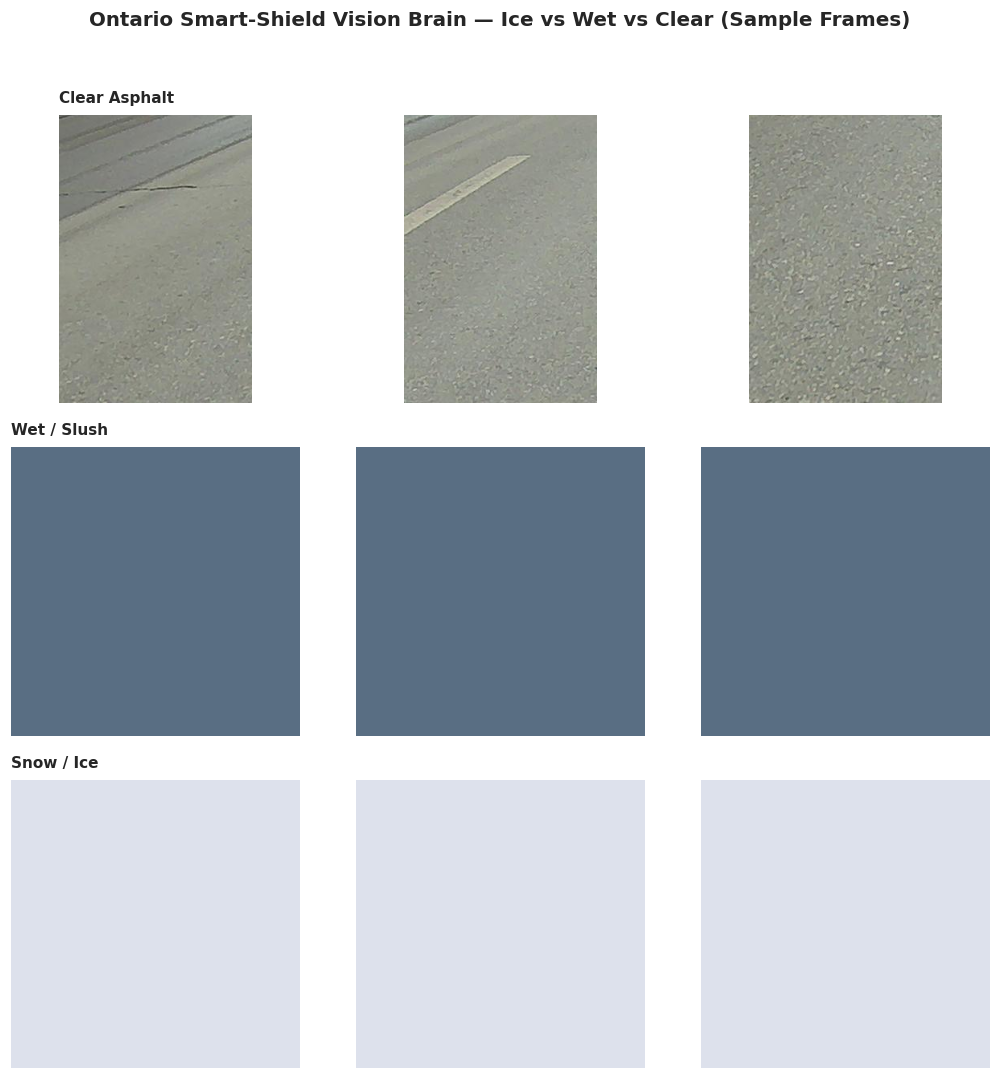

In [33]:
# ── 6.1  Display sample road-condition images ─────────────────────────────────
# Offline-first: reads Data/vision_cache/ or uses demo panels (no HuggingFace at runtime).
# Optional one-time seed: python seed_vision_cache.py

import sys
import importlib
from pathlib import Path

if "vision_brain" in sys.modules:
    del sys.modules["vision_brain"]
import vision_brain
importlib.reload(vision_brain)

from vision_brain import load_sample_images, display_condition_samples, DISPLAY_ORDER, resolve_cache_dir

VISION_CACHE = str((DATA.parent / "Data" / "vision_cache") if "DATA" in dir() else resolve_cache_dir())
SAMPLES_PER_CLASS = 3

sample_images, sample_labels = load_sample_images(
    n_per_class=SAMPLES_PER_CLASS,
    cache_dir=VISION_CACHE,
)

print("Conditions shown:", ", ".join(DISPLAY_ORDER))
print(f"Total sample images: {len(sample_images)}")
display_condition_samples(
    sample_images,
    sample_labels,
    title="Ontario Smart-Shield Vision Brain — Ice vs Wet vs Clear (Sample Frames)",
)


### 6.2 · Fine-Tune the Vision Model

We use **transfer learning**: start from ImageNet weights, replace the final layer for 3 road classes, and fine-tune on a subset (~120 images/class for speed).

| Setting | Value | Why |
|---------|-------|-----|
| Backbone | ResNet18 | Fast, good for demo + Colab |
| Input size | 224×224 RGB | Standard CNN input |
| Epochs | 8 | Enough to show learning without long waits |
| Metric | Val accuracy | Simple manager-friendly score |


Building training subset (offline cache / synthetic)...
Only 17 cached photos — using offline synthetic training set.
Train: 288  |  Val: 72  |  Classes: ['Clear Asphalt', 'Wet / Slush', 'Snow / Ice']
Fine-tuning on cpu for 8 epochs...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]


  Epoch 1/8  loss=0.2251  val_acc=69.44%
  Epoch 2/8  loss=0.0031  val_acc=69.44%
  Epoch 3/8  loss=0.0011  val_acc=100.00%
  Epoch 4/8  loss=0.0007  val_acc=100.00%
  Epoch 5/8  loss=0.0004  val_acc=100.00%
  Epoch 6/8  loss=0.0002  val_acc=100.00%
  Epoch 7/8  loss=0.0007  val_acc=100.00%
  Epoch 8/8  loss=0.0006  val_acc=100.00%


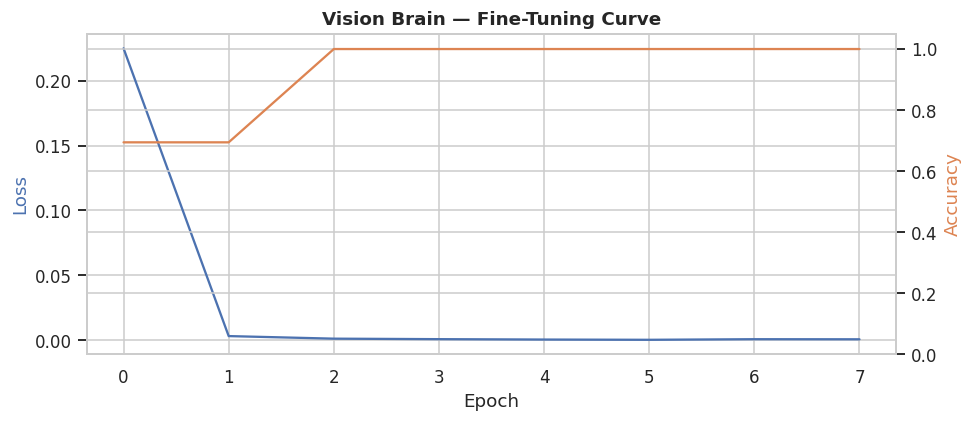


Vision Brain validation accuracy: 100.00%


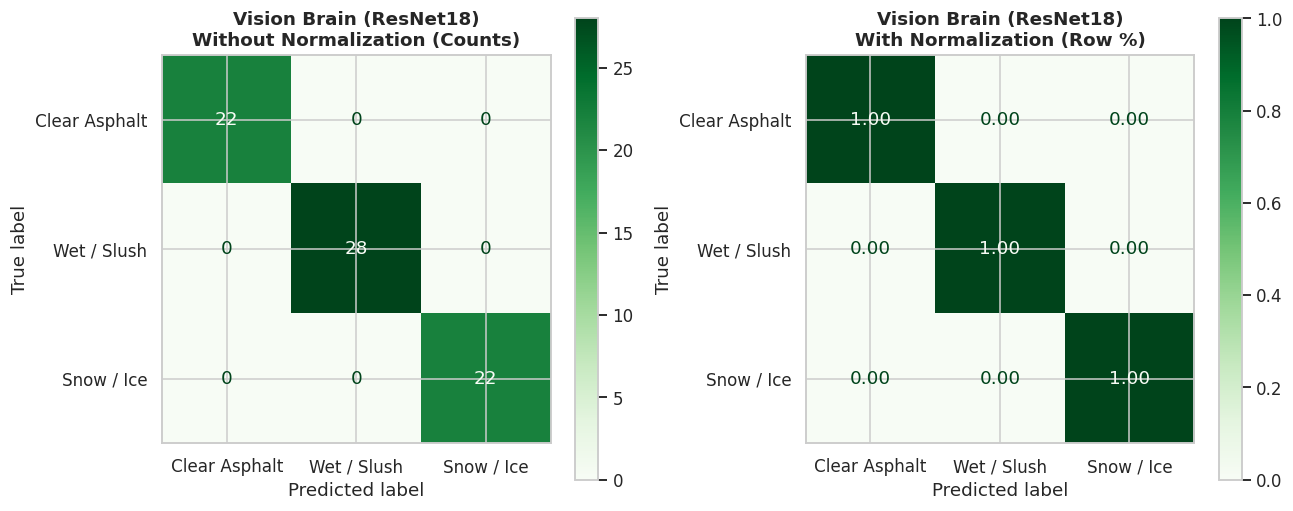

Example V-score (P(Snow/Ice)) on one frame: 0.000
  → This probability feeds the Safety Score S alongside NLP + tabular models.


In [34]:
# ── 6.2  Fine-tune ResNet18 on road-surface conditions ────────────────────────

vision_model = None
vision_history = None
vision_class_names = None
vision_val_acc = None

if not TORCH_OK:
    print("PyTorch not available (TORCH_OK=False). Install torch, restart kernel, rerun.")
else:
    import sys
    import importlib
    import torch

    if "vision_brain" in sys.modules:
        del sys.modules["vision_brain"]
    import vision_brain
    importlib.reload(vision_brain)

    from vision_brain import (
        build_training_dataset,
        fine_tune_vision_model,
        plot_vision_training,
        evaluate_vision_model,
        DISPLAY_ORDER,
        resolve_cache_dir,
    )
    from sklearn.metrics import ConfusionMatrixDisplay

    VISION_CACHE = str((DATA.parent / "Data" / "vision_cache") if "DATA" in dir() else resolve_cache_dir())
    VISION_TRAIN_PER_CLASS = 120
    VISION_EPOCHS = 8

    print("Building training subset (offline cache / synthetic)...")
    train_ds, val_ds, vision_class_names = build_training_dataset(
        max_per_class=VISION_TRAIN_PER_CLASS,
        cache_dir=VISION_CACHE,
    )
    print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Classes: {vision_class_names}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Fine-tuning on {device} for {VISION_EPOCHS} epochs...")
    vision_model, vision_history, vision_class_names = fine_tune_vision_model(
        train_ds, val_ds, epochs=VISION_EPOCHS, device=device,
    )
    plot_vision_training(vision_history)

    vision_val_acc, vision_cm, y_true, y_pred = evaluate_vision_model(
        vision_model, val_ds, vision_class_names, device=device,
    )
    print(f"\nVision Brain validation accuracy: {vision_val_acc:.2%}")

    plot_confusion_matrices_pair(
        y_true, y_pred, labels=vision_class_names,
        title_prefix="Vision Brain (ResNet18)",
        cmap="Greens",
    )

    vision_model.eval()
    x0, y0 = val_ds[0]
    with torch.no_grad():
        probs = torch.softmax(vision_model(x0.unsqueeze(0).to(device)), dim=1).cpu().numpy()[0]
    ice_idx = vision_class_names.index("Snow / Ice")
    v_score = float(probs[ice_idx])
    print(f"Example V-score (P(Snow/Ice)) on one frame: {v_score:.3f}")
    print("  → This probability feeds the Safety Score S alongside NLP + tabular models.")


In [ ]:
# ── PART SYNC → main notebook ──
import subprocess
import sys
from pathlib import Path

def _find_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "scripts" / "sync_notebook_parts.py").is_file():
            return base
    return Path.cwd()

_ROOT = _find_root()
rc = subprocess.run(
    [sys.executable, str(_ROOT / "scripts" / "sync_notebook_parts.py"),
     "--direction", "parts-to-main", "--only", "02_vision_brain.ipynb"],
    cwd=_ROOT,
).returncode
print("Synced to capstone_with_results.ipynb" if rc == 0 else f"Sync failed (exit {rc})")